In [257]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anastruct as ast

In [ ]:
ast.basic()

In [258]:
L_x = [6] # m
h_z = [4,3] # m
at = 6 # m

In [259]:
fc = 280 # kg/cm²
Ec = 15000 * fc**0.5 * 10 # ton/m²

c_b = 0.5
c_h = 0.5
v_b = 0.3
v_h = 0.6

A_c = c_b * c_h
I_c = c_b * c_h**3 / 12
A_v = v_b * v_h
I_v = v_b * v_h**3 / 12

In [260]:
ejes_x = [0]
for x in L_x: ejes_x.append(ejes_x[-1]+x)

ejes_z = [0]
for z in h_z: ejes_z.append(ejes_z[-1]+z)
print(ejes_x)
print(ejes_z)

[0, 6]
[0, 4, 7]


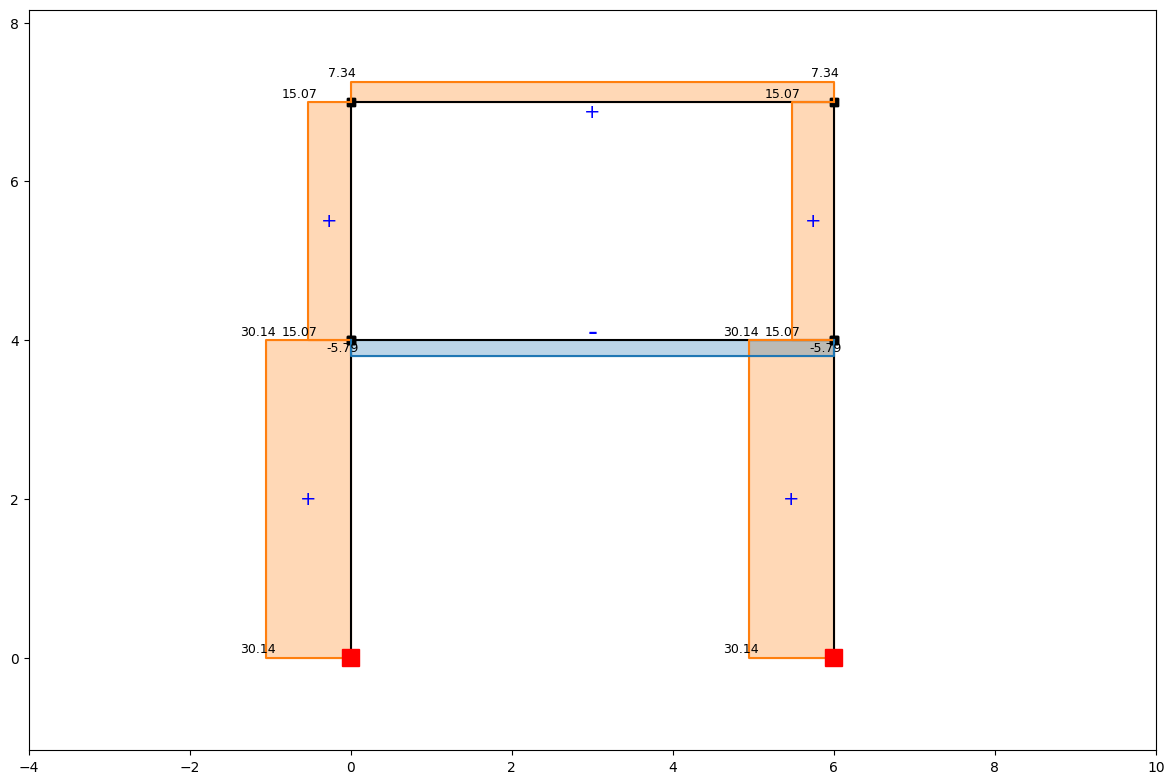

{'id': 1, 'Fx': np.float64(1.547634249556521), 'Fy': np.float64(30.14399999999999), 'Tz': np.float64(-2.12633938520636), 'ux': np.float64(0.0), 'uy': np.float64(-0.0), 'phi_z': np.float64(0.0)}
{'id': 4, 'Fx': np.float64(-1.5476342495565207), 'Fy': np.float64(30.144000000000005), 'Tz': np.float64(2.1263393852063803), 'ux': np.float64(0.0), 'uy': np.float64(-0.0), 'phi_z': np.float64(0.0)}


{'id': 5,
 'length': 6.0,
 'alpha': 0.0,
 'umax': np.float64(-6.494914113310185e-05),
 'umin': np.float64(-0.0001225963078192869),
 'u': array([-1.22596308e-04, -1.17984534e-04, -1.13564918e-04, -1.09337459e-04,
        -1.05302158e-04, -1.01459013e-04, -9.78080261e-05, -9.43491961e-05,
        -9.10825234e-05, -8.80080078e-05, -8.51256495e-05, -8.24354484e-05,
        -7.99374045e-05, -7.76315178e-05, -7.55177884e-05, -7.35962161e-05,
        -7.18668011e-05, -7.03295434e-05, -6.89844428e-05, -6.78314995e-05,
        -6.68707134e-05, -6.61020845e-05, -6.55256128e-05, -6.51412984e-05,
        -6.49491411e-05, -6.49491411e-05, -6.51412984e-05, -6.55256128e-05,
        -6.61020845e-05, -6.68707134e-05, -6.78314995e-05, -6.89844428e-05,
        -7.03295434e-05, -7.18668011e-05, -7.35962161e-05, -7.55177884e-05,
        -7.76315178e-05, -7.99374045e-05, -8.24354484e-05, -8.51256495e-05,
        -8.80080078e-05, -9.10825234e-05, -9.43491961e-05, -9.78080261e-05,
        -1.01459013e-04, -1.

In [261]:
ss = ast.SystemElements()

# modelamiento de columnas
for i in range(len(ejes_x)):
    for j in range(len(h_z)):
        ss.add_element([[ejes_x[i],ejes_z[j]],[ejes_x[i],ejes_z[j+1]]], EA = Ec*A_c, EI = Ec*I_c)

# modelamiento de vigas
for i in range(len(h_z)):
    for j in range(len(L_x)):
        ss.add_element([[ejes_x[j],ejes_z[i+1]],[ejes_x[j+1],ejes_z[i+1]]], EA = Ec*A_v, EI = Ec*I_v)

# Asignación de apoyos empotrados

for i in range(len(ejes_x)):
    ss.add_support_fixed(node_id=len(ejes_z)*i+1)

# Asignación de cargas

# Load Case Dead
w1 = 2.4 * 0.2 * at # Peso propio de la losa, ton/m
w2 = 2.4 * A_v # Peso propio de la viga, ton/m
w3 = at * (0.100 + 0.250) # acabados + tabiquería, ton/m
lc_D = ast.LoadCase("Dead")
for viga in range(len(ejes_x)*len(h_z)+1,len(ejes_x)*len(h_z)+len(h_z)*len(L_x)+1):
    lc_D.q_load(q = round(w1+w2+w3,2), element_id=viga)#, direction="y")

# Load Case Live
l1 = 0.250 * at # Peso propio de la losa, ton/m
lc_L = ast.LoadCase("Live")
for viga in range(len(ejes_x)*len(h_z)+1,len(ejes_x)*len(h_z)+len(h_z)*len(L_x)+1):
    lc_L.q_load(q = -round(l1,2), element_id=viga)#, direction="y")


# Load Case EarthQuake
lc_E = ast.LoadCase("EarthQuake")
E = [100, 130, 150,180]
for i in range(len(h_z)):
    for j in range(len(ejes_x)):
        lc_E.point_load(Fx=round(E[i]/len(ejes_x),1), node_id=2+j*len(ejes_z)+i)

Comb1 = ast.LoadCombination("Combo 1")
Comb1.add_load_case(lc_D, 1.4)
Comb1.add_load_case(lc_L, 1.7)

Comb2 = ast.LoadCombination("Combo 2")
Comb2.add_load_case(lc_D, 1.25)
Comb2.add_load_case(lc_L, 1.25)
Comb2.add_load_case(lc_E, 1)

Comb3 = ast.LoadCombination("Combo 3")
Comb3.add_load_case(lc_D, 1.25)
Comb3.add_load_case(lc_L, 1.25)
Comb3.add_load_case(lc_E, -1)

Comb4 = ast.LoadCombination("Combo 4")
Comb4.add_load_case(lc_D, 0.90)
Comb4.add_load_case(lc_E, 1)

Comb5 = ast.LoadCombination("Combo 5")
Comb5.add_load_case(lc_D, 0.90)
Comb5.add_load_case(lc_E, -1)



"""
ss.solve()
ss.show_structure(scale=0.7)
ss.show_bending_moment()
ss.show_axial_force()
ss.show_displacement(scale=0.7)
"""

res = Comb1.solve(ss)
s1 = res["combination"]
#s1.show_structure()
#s1.show_shear_force()
#s1.show_reaction_force(scale=0.7)
s1.show_axial_force(scale=1)

for x in ejes_x:
    print(s1.get_node_results_system(s1.find_node_id([x,0])))

s1.get_element_results(element_id=5, verbose=True)